In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")

## TASK 1 - One sample T-test

Null hypothesis (H₀): The mean wait time is 4.0 minutes.

Alternative hypothesis (H₁): The mean wait time is not 4.0 minutes.

In [2]:
wait_times = np.random.normal(loc=4.3, scale=1.2, size=35)

In [3]:
t_stat, p_value = st.ttest_1samp(wait_times, popmean=4.0)

t_stat, p_value

(np.float64(0.7450545455494864), np.float64(0.46135826637733657))

The p-value (0.461) is greater than 0.05. We fail to reject the null hypothesis.

**Interpretation:** There is no strong statistical evidence to suggest that the mean wait time is different from 4.0 minutes.

## TASK 2 - Two Sample T-test

H₀: The means of Group A and Group B are equal.

H₁: The means of Group A and Group B are not equal.

In [4]:
#generating data
group_a = np.random.normal(loc=52, scale=12, size=50)
group_b = np.random.normal(loc=57, scale=14, size=50)

In [5]:
#variance check
var_a = np.var(group_a, ddof=1)
var_b = np.var(group_b, ddof=1)

var_a, var_b

(np.float64(136.0601078603523), np.float64(169.25371691194957))

In [6]:
#Levene test
lev_stat, lev_p = st.levene(group_a, group_b)

lev_stat, lev_p

(np.float64(0.1394706424159864), np.float64(0.7096144854457804))

If Levene p-value < 0.05, variances are not equal.

If Levene p-value ≥ 0.05, variances are equal.

In [7]:
#deciding which test is correct
if lev_p < 0.05:
    t_stat2, p_value2 = st.ttest_ind(group_a, group_b, equal_var=False)
else:
    t_stat2, p_value2 = st.ttest_ind(group_a, group_b, equal_var=True)

t_stat2, p_value2

(np.float64(-2.26051641411263), np.float64(0.026001356171491255))

Since the p-value (0.0260) is less than 0.05, we reject the null hypothesis.

**Interpretation:** There is strong statistical evidence to suggest that the means of Group A and Group B are significantly different.

## TASK 3 Paired T-test

H₀: The mean difference is zero.

H₁: The mean difference is not zero.

A two-tailed test is used because we check for any change.

In [8]:
before = np.random.normal(loc=70, scale=8, size=30)
after = before + np.random.normal(loc=3, scale=5, size=30)

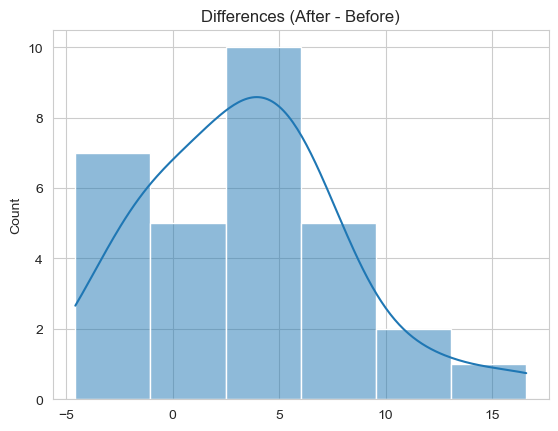

In [9]:
diff = after - before
sns.histplot(diff, kde=True)
plt.title("Differences (After - Before)")
plt.show()

In [10]:
t_stat3, p_value3 = st.ttest_rel(after, before)

t_stat3, p_value3

(np.float64(4.079159168339153), np.float64(0.0003225522319843029))

Since the p-value is less than 0.05, we reject the null hypothesis.

**Interpretation:** There is strong statistical evidence that the workflow change significantly affected productivity.

## Final 

Test used: Paired t-test.

Test statistic: t = 4.079

p-value: p = 0.00032